0️⃣ Setup

In [1]:
import numpy as np
import pymc as pm
import pytensor.tensor as pt
import arviz as az
import matplotlib.pyplot as plt

np.random.seed(42)


1️⃣ Generate synthetic irregular-time OU-DFA data
Dimensions and irregular time grid

In [2]:
T = 160
n_series = 10
k_factors = 3

time = np.cumsum(np.random.exponential(scale=1.0, size=T))
dt = np.diff(time)


True OU parameters

In [3]:
theta_true = np.array([0.4, 0.8, 1.3])
sigma_f_true = np.array([1.0, 0.7, 0.5])


Latent OU factors (irregular $\Delta t$)

In [4]:
f_true = np.zeros((T, k_factors))

for k in range(k_factors):
    for t in range(1, T):
        a = np.exp(-theta_true[k] * dt[t - 1])
        q = sigma_f_true[k] * np.sqrt((1 - a**2) / (2 * theta_true[k]))
        f_true[t, k] = a * f_true[t - 1, k] + q * np.random.randn()


Sparse identifiable loadings

In [5]:
Lambda_true = np.zeros((n_series, k_factors))
Lambda_true[0, 0] = 1.2
Lambda_true[1, 0] = -0.8
Lambda_true[1, 1] = 1.0
Lambda_true[2, 1] = -1.1
Lambda_true[3, 2] = 0.9
Lambda_true[4, 2] = -0.7


Observations

In [6]:
sigma_y_true = 0.4
Y = f_true @ Lambda_true.T + np.random.normal(
    0, sigma_y_true, size=(T, n_series)
)


2️⃣ Irregular-time OU-DFA with fully collapsed spike-and-slab
Prior hyperparameters

In [7]:
c0, d0 = 1.0, 4.0     # sparsity belief
c1, d1 = 2.0, 2.0     # slab strength

nu = 2.0 * c1
slab_sd = np.sqrt(d1 / c1)
spike_sd = 1e-6


Model

In [11]:
with pm.Model() as ou_dfa_collapsed:

    # Shared irregular time differences
    dt_shared = pm.Data("dt", dt)

    # -------------------------
    # OU latent factors
    # -------------------------
    theta = pm.Exponential("theta", 1.0, shape=k_factors)
    theta = pm.Deterministic("theta_ord", pt.sort(theta))

    sigma_f = pm.HalfNormal("sigma_f", 1.0, shape=k_factors)

    a = pm.Deterministic("a", pt.exp(-theta * dt_shared[:, None]))
    q = pm.Deterministic("q", sigma_f * pt.sqrt((1 - a**2) / (2 * theta)))

    f0 = pm.Normal("f0", 0.0, 1.0, shape=k_factors)
    eps = pm.Normal("eps", 0.0, 1.0, shape=(T - 1, k_factors))

    f_rest = a * f0 + q * eps
    f = pt.concatenate([[f0], pt.cumsum(f_rest, axis=0)])
    f = pm.Deterministic("f", f)

    # -------------------------
    # Collapsed spike-and-slab loadings (broadcast fixed)
    # -------------------------
    pi = pm.Beta("pi", c0, d0, shape=k_factors)  # inclusion probability per factor

    # Stack mixture weights on last axis
    w = pt.stack([1 - pi, pi], axis=-1)  # shape (k_factors, 2)
    w = pt.broadcast_to(w, (n_series, k_factors, 2))  # broadcast to all series

    Lambda_raw = pm.Mixture(
        "Lambda_raw",
        w=w,
        comp_dists=[
            pm.Normal.dist(0.0, spike_sd),
            pm.StudentT.dist(nu=nu, mu=0.0, sigma=slab_sd),
        ],
        shape=(n_series, k_factors),
    )

    # -------------------------
    # Identifiability constraints
    # -------------------------
    Lambda_lt = pt.tril(Lambda_raw)
    diag_idx = np.arange(k_factors)
    Lambda = pt.set_subtensor(
        Lambda_lt[diag_idx, diag_idx],
        pt.abs(Lambda_lt[diag_idx, diag_idx])
    )
    Lambda = pm.Deterministic("Lambda", Lambda)

    # -------------------------
    # Observation model
    # -------------------------
    sigma_y = pm.HalfNormal("sigma_y", 1.0, shape=n_series)
    mu = pt.math.dot(f, Lambda.T)
    y = pm.Normal("y", mu=mu, sigma=sigma_y, observed=Y)

    # -------------------------
    # Sample
    # -------------------------
    trace = pm.sample(draws=1000, tune=1000, chains=2, target_accept=0.9)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [theta, sigma_f, f0, eps, pi, Lambda_raw, sigma_y]


Output()

/u/zwu1/.conda/envs/gnpc/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)
/u/zwu1/.conda/envs/gnpc/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)


Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 397 seconds.
There were 1390 divergences after tuning. Increase `target_accept` or reparameterize.
Chain 1 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


3️⃣ Diagnostics

In [12]:
az.summary(
    trace,
    var_names=["theta_ord", "pi", "sigma_y"],
    round_to=2
)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
theta_ord[0],0.18,0.16,0.00,0.49,0.07,0.03,7.22,90.14,1.83
theta_ord[1],0.73,0.61,0.18,1.91,0.29,0.08,3.34,68.44,2.05
theta_ord[2],2.69,1.08,0.54,4.61,0.04,0.36,126.65,81.84,1.73
pi[0],0.79,0.10,0.57,0.91,0.04,0.02,6.08,170.90,2.00
pi[1],0.77,0.09,0.56,0.89,0.03,0.02,7.36,89.30,1.88
pi[2],0.75,0.08,0.58,0.91,0.00,0.03,261.88,71.33,1.78
sigma_y[0],0.38,0.04,0.31,0.46,0.00,0.01,84.35,75.79,1.74
sigma_y[1],0.41,0.05,0.33,0.46,0.03,0.00,3.07,14.18,1.79
sigma_y[2],0.49,0.04,0.40,0.52,0.02,0.01,6.16,76.26,1.75
sigma_y[3],0.46,0.02,0.42,0.50,0.00,0.01,18.04,95.58,1.83


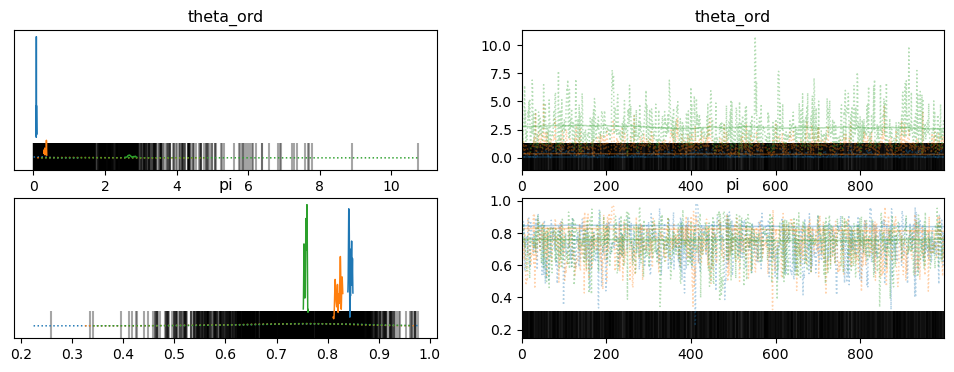

In [13]:
az.plot_trace(trace, var_names=["theta_ord", "pi"]);


4️⃣ Loadings recovery & sparsity check

In [14]:
Lambda_post = trace.posterior["Lambda"].mean(
    dim=("chain", "draw")
).values


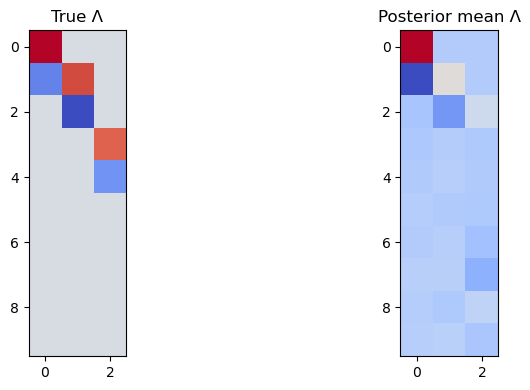

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(Lambda_true, cmap="coolwarm")
ax[0].set_title("True Λ")

ax[1].imshow(Lambda_post, cmap="coolwarm")
ax[1].set_title("Posterior mean Λ")

plt.tight_layout()
plt.show()


Posterior inclusion probabilities (no thresholds)

In [16]:
Lambda_samples = trace.posterior["Lambda_raw"]

slab_prob = (
    np.abs(Lambda_samples) > 3 * spike_sd
).mean(dim=("chain", "draw")).values


5️⃣ Latent OU factor recovery

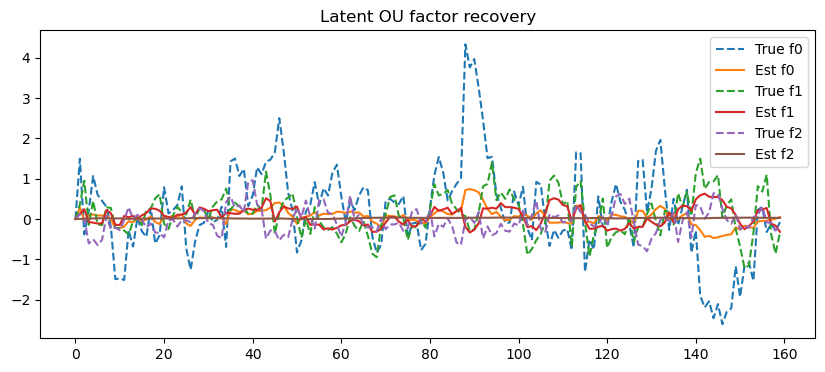

In [17]:
f_post = trace.posterior["f"].mean(
    dim=("chain", "draw")
).values

plt.figure(figsize=(10, 4))
for k in range(k_factors):
    plt.plot(f_true[:, k], "--", label=f"True f{k}")
    plt.plot(f_post[:, k], label=f"Est f{k}")
plt.legend()
plt.title("Latent OU factor recovery")
plt.show()


6️⃣ Posterior predictive checks (PPCs)
Sample posterior predictive